## Feature Engineering

The objective of feature engineering is to improve signal quality by filtering market noise and encoding trend, momentum, volatility, and intraday seasonal effects into a model-ready dataset.

---

### 3.1 Technical Filters

To reduce false positives in noisy intraday markets, the following classical technical indicators were engineered:

- **EMA (Exponential Moving Average)**  
  *Purpose:* Trend identification and regime filtering  
  *Usage:* Filters counter-trend trades (e.g., avoiding long positions when price is below EMA 50)

- **RSI (Relative Strength Index)**  
  *Purpose:* Momentum and mean reversion  
  *Usage:*  
  - Overbought: RSI > 70  
  - Oversold: RSI < 30  

- **MACD (Moving Average Convergence Divergence)**  
  *Purpose:* Trend strength and momentum confirmation  
  *Usage:* Signal line crossovers and histogram magnitude

- **Bollinger Bands**  
  *Purpose:* Volatility and relative price positioning  
  *Usage:* Identifies volatility contractions (squeeze) and breakout extensions

---

### 3.2 Time & Session Features

To capture intraday seasonality and session-specific market behavior, the following time-based features were engineered:

- **Hour of the day (0–23)**  
  Captures broad intraday trading patterns.

- **Minute of the hour (0–59)**  
  Provides fine-grained timing information.

- **Day of the week (0–4)**  
  Encodes weekday effects (Monday to Friday).

- **Continuous time representation (`time_float`)**  
  Defined as hour + minute / 60, enabling precise temporal filtering (e.g., excluding trades after a specific intraday threshold).

- **Session indicators (binary variables):**  
  - *European open:* Early European trading hours  
  - *New York open:* High-liquidity US market open  
  - *Late session:* Reduced-liquidity evening hours  


In [6]:
import pandas as pd
import numpy as np

# =========================
# Load dataset
# =========================

final_path = "Datasets/final_dataset.csv"
data = pd.read_csv(final_path, parse_dates=['timestamp'], index_col='timestamp')

# =========================
# Technical Indicators
# =========================

price = data['NQ_close']

# EMA (50)
data['ema_50'] = price.ewm(span=50, adjust=False).mean()

# Bollinger Bands (20, 2)
data['sma_20'] = price.rolling(window=20).mean()
rolling_std = price.rolling(window=20).std()
data['bb_upper'] = data['sma_20'] + 2 * rolling_std
data['bb_lower'] = data['sma_20'] - 2 * rolling_std

# RSI (14)
delta = price.diff()
gain = delta.clip(lower=0).rolling(window=14).mean()
loss = -delta.clip(upper=0).rolling(window=14).mean()
rs = gain / loss
data['rsi'] = 100 - (100 / (1 + rs))
data['rsi'] = data['rsi'].fillna(50)

# MACD (12, 26, 9)
ema_fast = price.ewm(span=12, adjust=False).mean()
ema_slow = price.ewm(span=26, adjust=False).mean()
data['macd_line'] = ema_fast - ema_slow
data['macd_signal'] = data['macd_line'].ewm(span=9, adjust=False).mean()
data['macd_hist'] = data['macd_line'] - data['macd_signal']

# =========================
# Time & Session Features
# =========================

data['time_float'] = data['Hour'] + data['Minute'] / 60.0
data['is_eu_open'] = ((data['time_float'] >= 9.0) & (data['time_float'] < 11.0)).astype(int)
data['is_ny_open'] = ((data['time_float'] >= 15.5) & (data['time_float'] < 17.0)).astype(int)
data['is_late_session'] = (data['time_float'] >= 20.0).astype(int)

# =========================
# Final cleanup
# =========================

data.dropna(inplace=True)

# Check final dataset
print("Feature engineering complete!")
print("Shape:", data.shape)
print("Columns:", data.columns.tolist())


Feature engineering complete!
Shape: (681567, 32)
Columns: ['BTC_open', 'BTC_high', 'BTC_low', 'BTC_close', 'BTC_volume', 'NQ_open', 'NQ_high', 'NQ_low', 'NQ_close', 'NQ_volume', 'BTC_return', 'NQ_return', 'BTC_vol', 'NQ_vol', 'BTC_dir', 'NQ_dir', 'agreement', 'divergence', 'Hour', 'Minute', 'ema_50', 'sma_20', 'bb_upper', 'bb_lower', 'rsi', 'macd_line', 'macd_signal', 'macd_hist', 'time_float', 'is_eu_open', 'is_ny_open', 'is_late_session']


In [6]:
# Save analytical dataset

analytical_path = "Datasets/analytical_dataset.csv"
data.to_csv(analytical_path)
print(f"Analytical dataset saved to {analytical_path}")
print("Shape after feature engineering:", data.shape)


Analytical dataset saved to Datasets/analytical_dataset.csv
Shape after feature engineering: (681567, 32)


# Target Construction & Prediction Framework

## Objective

The objective of this stage is to define a **clear, forward-looking target variable**.
---

## Prediction Horizon

The model operates at a **1-minute frequency**.  
At each time step $ t $, the model has access only to information available up to that moment and is tasked with predicting the **direction of the market at time $ t+1 $**.

This formulation ensures:
- Causal consistency
- No information leakage
- Compatibility with real-time trading systems


## Target Definition

Let $ P_t $ denote the NQ close price at time $ t $.

The **one-minute forward log return** is defined as:

$$
r_{t+1} = \log\left(\frac{P_{t+1}}{P_t}\right)
$$

The binary target variable is constructed as:

$$
y_t =
\begin{cases}
1 & \text{if } r_{t+1} > 0 \\
0 & \text{otherwise}
\end{cases}
$$

Where:
- **1** indicates an upward price movement in the next minute
- **0** indicates a flat or downward movement

This formulation transforms the problem into a **binary classification task**.

---

## Rationale for Using $ t+1 $ as Target

Using the next-period return $ t+1 $ is a standard approach in financial machine learning due to the following reasons:

- Prevents look-ahead bias
- Ensures that predictions are genuinely forward-looking
- Aligns with market microstructure at high frequencies
- Provides a well-defined and interpretable learning objective

Alternative horizons (e.g. $ t+5 $, $ t+10 $) were not used to avoid unnecessary complexity and signal dilution.

---

## Baseline Strategy as Benchmark

A **naïve momentum-based baseline** is used as a reference model:

- If the current return is positive → predict upward movement
- If the current return is negative → predict downward movement

The baseline does **not** define the target, but rather serves as a **benchmark** against which more sophisticated models are evaluated.

This allows for a meaningful comparison and helps assess whether engineered features and machine learning models provide predictive value beyond simple heuristics.

---

## Data Alignment

Because the target depends on $ t+1 $, the final observation in the dataset cannot be labeled and is therefore removed. All remaining observations are properly aligned such that:

- Features are computed using information available at time $ t $
- The target represents the market outcome at time $ t+1 $

This guarantees a clean and realistic supervised learning setup.

In [7]:
import pandas as pd
import numpy as np

# =========================
# Load analytical dataset
# =========================

analytical_path = "Datasets/analytical_dataset.csv"
data = pd.read_csv(analytical_path, parse_dates=['timestamp'], index_col='timestamp')

print("Dataset loaded")
print("Initial shape:", data.shape)

# =========================
# Drop rows with NaNs in critical columns
# =========================

# List all columns needed for modeling / target
required_cols = ['NQ_close']  # add more features if needed

rows_before = len(data)
data = data.dropna(subset=required_cols)
rows_after = len(data)
print(f"Rows removed due to NaNs: {rows_before - rows_after}")

# =========================
# Target Construction (t+1)
# =========================

# Forward 1-minute log return
data['NQ_return_t_plus_1'] = np.log(data['NQ_close'].shift(-1) / data['NQ_close'])

# Binary classification target: 1 if return > 0, else 0
data['target'] = (data['NQ_return_t_plus_1'] > 0).astype(int)

# Drop last row (no t+1 available)
data = data.iloc[:-1]

# =========================
# Summary
# =========================

print("Final shape after target construction:", data.shape)
print("Target distribution:")
print(data['target'].value_counts(normalize=True))


Dataset loaded
Initial shape: (681567, 32)
Rows removed due to NaNs: 0
Final shape after target construction: (681566, 34)
Target distribution:
target
0    0.50169
1    0.49831
Name: proportion, dtype: float64


In [9]:
# Save model-ready dataset

model_data_path = "Datasets/model_ready_dataset.csv"
data.to_csv(model_data_path)

print(f"Model-ready dataset saved to {model_data_path}")

Model-ready dataset saved to Datasets/model_ready_dataset.csv


## 2. Chronological Split

After constructing the target (`t+1` NQ return) and cleaning the dataset, we split the dataset chronologically to prevent **look-ahead bias**.

### 2.1 Chronological Split

- **Training set:** first 60% of the dataset  
- **Validation set:** next 20%  
- **Test set:** last 20%  


### 2.2 Feature Scaling

We normalize all input features (except the target columns) using **StandardScaler**:

- StandardScaler subtracts the **mean** and divides by the **standard deviation** of each feature.
- The scaler is **fitted on the training set** only, then applied to validation and test sets to avoid data leakage.


In [8]:
from sklearn.preprocessing import StandardScaler

# Chronological split: 60/20/20
n = len(data)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

train_data = data.iloc[:train_end].copy()
val_data   = data.iloc[train_end:val_end].copy()
test_data  = data.iloc[val_end:].copy()

print("\nDataset shapes:")
print("Train:", train_data.shape)
print("Validation:", val_data.shape)
print("Test:", test_data.shape)

# Feature scaling

# Exclude target columns from scaling
target_cols = ['NQ_return_t_plus_1', 'target']
feature_cols = [col for col in data.columns if col not in target_cols]

scaler = StandardScaler()

# Fit on train, transform on train/val/test
train_data[feature_cols] = scaler.fit_transform(train_data[feature_cols])
val_data[feature_cols] = scaler.transform(val_data[feature_cols])
test_data[feature_cols] = scaler.transform(test_data[feature_cols])

print("\nFeature scaling completed.")


Dataset shapes:
Train: (408939, 34)
Validation: (136313, 34)
Test: (136314, 34)

Feature scaling completed.


## Modelling


### SVM

In [1]:
import pandas as pd
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# =========================
# 1️⃣ Load dataset
# =========================
model_data_path = "Datasets/model_ready_dataset.csv"
data = pd.read_csv(model_data_path, parse_dates=['timestamp'], index_col='timestamp')

# =========================
# 2️⃣ Define features and target
# =========================
target_cols = ['NQ_return_t_plus_1', 'target']
feature_cols = [col for col in data.columns if col not in target_cols]

# =========================
# 3️⃣ Split train/validation
# =========================
n = len(data)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

train_data = data.iloc[:train_end].copy()
val_data   = data.iloc[train_end:val_end].copy()

X_train, y_train = train_data[feature_cols], train_data['target']
X_val, y_val     = val_data[feature_cols], val_data['target']

# =========================
# 4️⃣ GridSearchCV with PredefinedSplit
# =========================
X_grid = pd.concat([X_train, X_val])
y_grid = pd.concat([y_train, y_val])

split_index = np.concatenate([
    -1 * np.ones(len(X_train)),
    np.zeros(len(X_val))
])
ps = PredefinedSplit(test_fold=split_index)

# =========================
# Maxed-out LinearSVC
# =========================
svm = LinearSVC(
    max_iter=20000,        # more iterations
    tol=1e-5,              # tighter convergence
    random_state=42,
    class_weight='balanced',
    dual=False,            # faster if n_samples > n_features
    penalty='l2',
    loss='squared_hinge',
    multi_class='ovr'
)

param_grid = {'C': [0.001, 0.01, 0.1, 1, 5, 10, 50, 100]}

grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=ps,
    scoring='accuracy',
    n_jobs=-1
)

print("Running MAX LinearSVC hyperparameter tuning...")
grid_search.fit(X_grid, y_grid)

best_svm = grid_search.best_estimator_
print(f"Best C found: {grid_search.best_params_['C']}")
print(f"Best validation accuracy: {grid_search.best_score_:.4f}")

# =========================
# 5️⃣ Model evaluation
# =========================
def evaluate_model(model, X, y, set_name="Validation"):
    y_pred = model.predict(X)
    print(f"\n=== {set_name} Set Evaluation ===")
    print("Accuracy:", accuracy_score(y, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y, y_pred))
    print("\nClassification Report:\n", classification_report(y, y_pred))
    return y_pred

y_train_pred = evaluate_model(best_svm, X_train, y_train, set_name="Train")
y_val_pred   = evaluate_model(best_svm, X_val, y_val, set_name="Validation")

# =========================
# 6️⃣ Trading/backtesting
# =========================
def generate_signals(predictions: np.ndarray) -> pd.Series:
    return pd.Series(np.where(predictions == 1, 1, -1), index=val_data.index)

def backtest_strategy(df: pd.DataFrame, signal_col='signal', return_col='NQ_return_t_plus_1'):
    df['strategy_return'] = df[return_col] * df[signal_col]
    df['cumulative_pnl'] = df['strategy_return'].cumsum()
    total_return = df['cumulative_pnl'].iloc[-1]
    sharpe_ratio = df['strategy_return'].mean() / df['strategy_return'].std() * np.sqrt(252)
    return df, total_return, sharpe_ratio

val_data['signal'] = generate_signals(y_val_pred)
val_data, total_return, sharpe_ratio = backtest_strategy(val_data)

print("\n=== Validation Trading Simulation Results ===")
print(f"Total Strategy Return: {total_return:.4f}")
print(f"Strategy Sharpe Ratio (annualized): {sharpe_ratio:.2f}")

print("\nSample trades:")
print(val_data[['NQ_return_t_plus_1', 'signal', 'strategy_return', 'cumulative_pnl']].tail(10))


Running MAX LinearSVC hyperparameter tuning...
Best C found: 10
Best validation accuracy: 0.5079

=== Train Set Evaluation ===
Accuracy: 0.5100809656207894

Confusion Matrix:
 [[106563  98194]
 [102153 102029]]

Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.52      0.52    204757
           1       0.51      0.50      0.50    204182

    accuracy                           0.51    408939
   macro avg       0.51      0.51      0.51    408939
weighted avg       0.51      0.51      0.51    408939


=== Validation Set Evaluation ===
Accuracy: 0.5061072678321217

Confusion Matrix:
 [[35686 32834]
 [34490 33303]]

Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.52      0.51     68520
           1       0.50      0.49      0.50     67793

    accuracy                           0.51    136313
   macro avg       0.51      0.51      0.51    136313
weighted avg       0.51  

#### Equity Curve - SVM

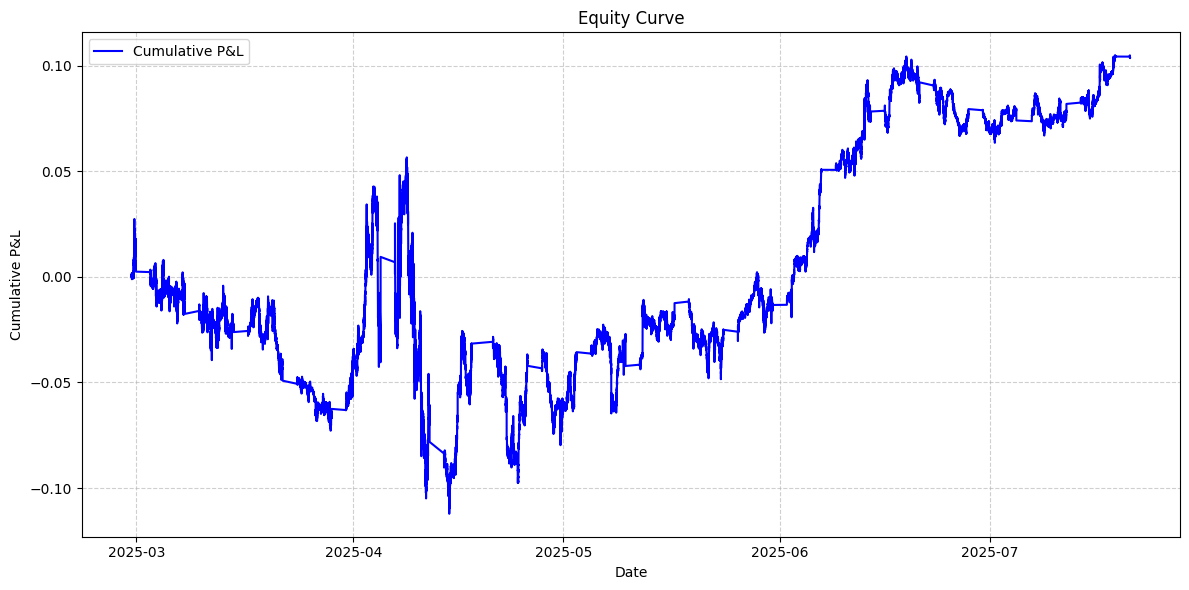

In [2]:
import matplotlib.pyplot as plt

# =========================
# 7️⃣ Equity Curve Visualization
# =========================
def plot_equity_curve(df: pd.DataFrame, cumulative_col: str = 'cumulative_pnl', title: str = "Equity Curve"):
    """
    Plots cumulative P&L over time.
    """
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df[cumulative_col], label='Cumulative P&L', color='blue')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Cumulative P&L')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Call the function to plot
plot_equity_curve(val_data)


### Logistic Regression

### Random Forest

### Comparison of Algos

### Integration with Baseline Strategy

### Evaluation of ML Optimized VS Baseline